# Random Forest Classifier — Ensemble Learning

## 1. Problem Setup

Assume we have a dataset

$$
\{(x_i, y_i)\}_{i=1}^{N}
$$

where

$$
x_i \in \mathbb{R}^D
$$

is the feature vector and

$$
y_i \in \{1, 2, \dots, K\}
$$

is the class label.

The goal is to build a robust classifier that reduces overfitting and improves generalization.

---

## 2. Motivation

A single decision tree has:

- **Low bias**
- **High variance**

Random Forest reduces variance by averaging multiple trees.

---

## 3. Bootstrap Sampling (Bagging)

For each tree $b = 1, \dots, B$:

Sample dataset with replacement:

$$
D^{(b)} \sim \text{Bootstrap}(D)
$$

Each tree sees a slightly different dataset.

---

## 4. Feature Randomness

At each split, instead of using all features, we randomly select a subset:

$$
m = \lfloor \text{feature\_fraction} \cdot D \rfloor
$$

This introduces diversity among trees.

---

## 5. Tree Training

Each tree is trained independently:

$$
T_b = \text{DecisionTree}(D^{(b)})
$$

using:

- Random subset of samples  
- Random subset of features  

---

## 6. Ensemble Model

The Random Forest consists of $B$ trees:

$$
\{T_1, T_2, \dots, T_B\}
$$

---

## 7. Prediction Rule (Majority Voting)

For a test sample $x$:

$$
\hat{y} = \text{mode} \{T_1(x), T_2(x), \dots, T_B(x)\}
$$

---

## 8. Out-of-Bag (OOB) Samples

For each sample $i$, define OOB set:

$$
\mathcal{B}_i = \{b : x_i \notin D^{(b)}\}
$$

These trees did not see $x_i$ during training.

---

## 9. OOB Prediction

For sample $i$:

$$
\hat{y}_i^{OOB} = \text{mode} \{T_b(x_i) : b \in \mathcal{B}_i\}
$$

---

## 10. OOB Accuracy

The OOB estimate of accuracy is:

$$
\text{Accuracy}_{OOB} =
\frac{1}{N} \sum_{i=1}^{N} \mathbf{1}(\hat{y}_i^{OOB} = y_i)
$$

---





## 11. Variance Reduction of Random Forest 

### I. Setup

Consider a Random Forest with $B$ trees.

Each tree produces a prediction:

$$
T_b(x), \quad b = 1, 2, \dots, B
$$

The ensemble prediction is the average:

$$
\hat{f}_{RF}(x) = \frac{1}{B} \sum_{b=1}^{B} T_b(x)
$$



### II. Assumptions

We assume:

1. Equal variance for all trees:

$$
\text{Var}(T_b(x)) = \sigma^2
$$

2. Constant pairwise correlation:

$$
\text{Corr}(T_i(x), T_j(x)) = \rho \quad \forall i \neq j
$$

3. Covariance between trees:

$$
\text{Cov}(T_i(x), T_j(x)) = \rho \sigma^2
$$



### III. Variance of the Ensemble

We compute:

$$
\text{Var}(\hat{f}_{RF}(x)) =
\text{Var} \left( \frac{1}{B} \sum_{b=1}^{B} T_b(x) \right)
$$

Using scaling property:

$$
= \frac{1}{B^2} \text{Var} \left( \sum_{b=1}^{B} T_b(x) \right)
$$



### IV. Expanding the Variance

Using:

$$
\text{Var}\left(\sum T_b\right) =
\sum \text{Var}(T_b) + \sum_{i \neq j} \text{Cov}(T_i, T_j)
$$

we get:

$$
\text{Var}(\hat{f}_{RF}) =
\frac{1}{B^2}
\left(
\sum_{b=1}^{B} \sigma^2 +
\sum_{i \neq j} \rho \sigma^2
\right)
$$



### V. Counting Terms

Variance terms:

$$
\sum_{b=1}^{B} \sigma^2 = B \sigma^2
$$

Covariance terms:

$$
\sum_{i \neq j} 1 = B(B-1)
$$

Thus:

$$
\sum_{i \neq j} \rho \sigma^2 = B(B-1)\rho \sigma^2
$$



### VI. Substituting Back

$$
\text{Var}(\hat{f}_{RF}) =
\frac{1}{B^2}
\left(
B\sigma^2 + B(B-1)\rho \sigma^2
\right)
$$

Factor out $\sigma^2$:

$$
= \frac{\sigma^2}{B^2}
\left(
B + B(B-1)\rho
\right)
$$



### VII. Simplification

$$
= \frac{\sigma^2}{B^2} \cdot B \left(1 + (B-1)\rho \right)
$$

$$
= \frac{\sigma^2}{B} \left(1 + (B-1)\rho \right)
$$



### VIII. Rearranging Terms

$$
= \frac{\sigma^2}{B} + \frac{(B-1)\rho \sigma^2}{B}
$$

Rewrite:

$$
= \frac{\sigma^2}{B} + \rho \sigma^2 \left(1 - \frac{1}{B}\right)
$$



### IX. Final Expression

$$
\boxed{
\text{Var}(\text{RF}) =
\rho \sigma^2 + \frac{1 - \rho}{B} \sigma^2
}
$$



### X. Special Case: Independent Trees

If trees are independent:

$$
\rho = 0
$$

then:

$$
\text{Var}(\text{RF}) = \frac{\sigma^2}{B}
$$



### XI. Interpretation

- Term 1:

$$
\rho \sigma^2
$$

→ irreducible variance due to correlation  

- Term 2:

$$
\frac{1 - \rho}{B} \sigma^2
$$

→ reducible variance via averaging  



### XII. Note

- Increasing $B$ reduces only the second term  
- High correlation limits improvement  
- Low correlation enables strong variance reduction  



### XIII. Conclusion

Random Forest performance depends on:

$$
\text{Low correlation} + \text{Large } B
$$

Feature randomness ensures:

$$
\rho \downarrow \Rightarrow \text{Var}(\text{RF}) \downarrow
$$

---

## 12. Role of Feature Randomness

Feature subsampling reduces correlation:

$$
\rho \downarrow \Rightarrow \text{Var}(\text{RF}) \downarrow
$$

This is key to Random Forest performance.

---

## 13. Bias–Variance Tradeoff

- Increasing trees ($B \uparrow$):

$$
\text{Variance} \downarrow
$$

- Feature randomness:

$$
\text{Variance} \downarrow
$$

- Trees remain low bias → overall strong model

---

## 14. Algorithm Summary

For $b = 1$ to $B$:

1. Sample dataset $D^{(b)}$ with replacement  
2. Train decision tree using:
   - Random samples  
   - Random feature subsets  



Prediction:

$$
\hat{y} = \text{mode}\{T_b(x)\}_{b=1}^{B}
$$

---

## 15. Important

Random Forest combines:

- **Bagging (bootstrap sampling)**
- **Feature randomness**
- **Ensemble averaging**

to produce a model that is:

- Robust  
- Low variance  
- Highly generalizable  

---

## 16. Final Perspective

Random Forest approximates:

$$
\mathbb{E}_{D^{(b)}, \text{features}} [T(x)]
$$

i.e., an **expectation over multiple randomized trees**, leading to stable predictions.

In [1]:
class LeafNode:
    """Leaf node of a decision tree storing the predicted value."""
    def __init__(self, value):
        self.value = value

In [2]:
class DecisionNode:
    """Internal decision node of a decision tree.

    Attributes:
        best_feature (int): Index of the feature used for splitting.
        best_threshold (float): Threshold value used for splitting.
        left_child (DecisionNode or LeafNode): Left subtree.
        right_child (DecisionNode or LeafNode): Right subtree.
    """
    def __init__(self, best_feature, best_threshold, left_child, right_child):
        self.best_feature = best_feature
        self.best_threshold = best_threshold
        self.left_child = left_child
        self.right_child = right_child

In [3]:
class DecisionTree:
    """Decision Tree Classifier supporting Gini or Entropy splitting criteria.

    Attributes:
        max_depth (int): Maximum depth of the tree.
        min_samples_split (int): Minimum samples required to split a node.
        scoring (str): Splitting criterion ('gini' or 'entropy').
        feature_fraction (float): Fraction of features to consider at each split (for randomization).
        root (DecisionNode): Root node of the tree.
    """
    def __init__(self, max_depth=10, min_samples_split=1, scoring='gini', feature_fraction=1.0):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.scoring = scoring
        self.feature_fraction = feature_fraction
        self.root = None

        # Input validation
        if type(self.max_depth) != int or self.max_depth <= 0:
            raise ValueError('Max depth must be a positive integer')
        if type(self.min_samples_split) != int or self.min_samples_split <= 0:
            raise ValueError('Min samples split must be a positive integer')
        if self.scoring not in ['gini', 'entropy']:
            raise ValueError("Scoring must be either 'gini' or 'entropy'")

    def _stopping_condition(self, data, depth):
        """Check if tree building should stop at current node."""        
        if depth >= self.max_depth:
            return True
        if len(data) < self.min_samples_split:
            return True
        if len(np.unique(data[:, -1])) == 1:
            return True
        return False

    def _score(self, left, right):
        """Compute the weighted impurity score of a split."""
        n_left = len(left)
        n_right = len(right)
        total = n_left + n_right

        if n_left == 0 or n_right == 0:
            return np.inf # invalid split

        counts_left = np.unique(left, return_counts=True)[1]
        counts_right = np.unique(right, return_counts=True)[1]

        probability_left = counts_left / np.sum(counts_left)
        probability_right = counts_right / np.sum(counts_right)

        if self.scoring == 'gini':
            score_left = 1 - np.sum(probability_left**2)
            score_right = 1 - np.sum(probability_right**2)
        else:  # entropy
            score_left = -np.sum(probability_left * np.log(probability_left))
            score_right = -np.sum(probability_right * np.log(probability_right))

        return (n_left * score_left + n_right * score_right) / total

    def _random_feature(self, data):
        """Select a random subset of features for splitting."""
        n_features = data.shape[1] - 1  # exclude target
        n_selected = max(1, int(round(n_features * self.feature_fraction)))
        selected_features = np.random.choice(n_features, n_selected, replace=False)
        return selected_features


    def _find_all_threshold(self, data, selected_features):
        """Find all candidate thresholds for each selected feature."""
        all_thresholds = []
        for feature in selected_features:
            unique_vals = np.unique(data[:, feature])
            if len(unique_vals) <= 1:
                all_thresholds.append(np.array([]))
            else:
                successive_average = (unique_vals[1:] + unique_vals[:-1]) / 2
                all_thresholds.append(successive_average)
        return all_thresholds

    def _split(self, data, feature, threshold):
        """Split data into left and right subsets based on feature threshold."""
        condition = data[:, feature] <= threshold
        return data[condition], data[~condition]

    def _best_feature_threshold(self, data, selected_features, all_thresholds):
        """Find the best feature and threshold to split the data."""
        best_score = np.inf
        best_feature = None
        best_threshold = None

        for i, feature in enumerate(selected_features):
            thresholds = all_thresholds[i]
            if len(thresholds) == 0:
                continue
            for threshold in thresholds:
                left, right = self._split(data, feature, threshold)
                score = self._score(left[:, -1], right[:, -1])
                if score < best_score:
                    best_score = score
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _find_best_split(self, data):
        """Select best split among random subset of features."""
        selected_features = self._random_feature(data)
        all_thresholds = self._find_all_threshold(data, selected_features)
        best_feature, best_threshold = self._best_feature_threshold(data, selected_features, all_thresholds) 
        return best_feature, best_threshold

    def _build_tree(self, data, depth):
        """Recursively build the decision tree."""
        if self._stopping_condition(data, depth):
            prediction = stats.mode(data[:, -1])[0]
            return LeafNode(prediction)

        best_feature, best_threshold = self._find_best_split(data)
        left_data, right_data = self._split(data, best_feature, best_threshold)

        left_child = self._build_tree(left_data, depth + 1)
        right_child = self._build_tree(right_data, depth + 1)

        return DecisionNode(best_feature, best_threshold, left_child, right_child)

    def fit(self, X, y):
        """Train the decision tree on the dataset."""
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1, 1)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        data = np.hstack((X, y))
        self.root = self._build_tree(data, 0)

    def _predict_single(self, x, node):
        """Predict the label for a single sample recursively."""
        if isinstance(node, LeafNode):
            return node.value
        if x[node.best_feature] <= node.best_threshold:
            return self._predict_single(x, node.left_child)
        else:
            return self._predict_single(x, node.right_child)

    def predict(self, X):
        """Predict labels for multiple samples."""
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        return np.array([self._predict_single(x, self.root) for x in X])

In [4]:
class RandomForestClassifier:
    """Custom Random Forest Classifier using DecisionTree as base learner.

    Attributes:
        ntrees (int): Number of trees in the forest.
        max_depth (int): Maximum depth of each tree.
        min_samples_split (int): Minimum samples to split a node.
        scoring (str): Split criterion ('gini' or 'entropy').
        feature_fraction (float): Fraction of features to consider per tree.
        sample_fraction (float): Fraction of dataset sampled for each tree.
        oob_score (bool): Whether to calculate out-of-bag score.
        all_trees (list): List of trained DecisionTree instances.
        oob_score_ (float): Calculated out-of-bag score.
    """
    def __init__(self, ntrees=10, max_depth=10, min_samples_split=1, scoring='gini', feature_fraction=1.0 , sample_fraction=1 ,oob_score=False):
        self.ntrees = ntrees
        self.max_depth=max_depth
        self.min_samples_split = min_samples_split
        self.scoring = scoring
        self.feature_fraction = feature_fraction
        self.sample_fraction = sample_fraction
        self.oob_score = oob_score
        self.all_trees = []
        self.oob_score_ =None

    def sampling(self,data):
        """Bootstrap sampling with optional OOB tracking."""
        N = round(len(data) * self.sample_fraction)        
        all_indices = np.arange(len(data))            # full dataset indices
        sampled_indices = np.random.choice(all_indices, size=N, replace=True)
        oob_index = np.setdiff1d(all_indices,sampled_indices)

        return sampled_indices, oob_index

    def fit(self,X,y):
        """Train the Random Forest on the dataset."""
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1, 1)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        data = np.column_stack((X,y))
        N = len(data)
        
        self.oob_preds = [[] for _ in range(N)]
        
        for i in range(self.ntrees):
            
            model = (DecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split, 
                                  scoring=self.scoring, feature_fraction=self.feature_fraction))
            
            sampled_indices, oob_indices = self.sampling(data)

            data_sampled = data[sampled_indices]
            model.fit(data_sampled[:,:-1] , data_sampled[:,-1])

            self.all_trees.append(model)
            
            # Track OOB predictions
            if self.oob_score:
                for idx in oob_indices:

                    pred = model.predict(data[idx, :-1].reshape(1,-1))[0]
                
                    self.oob_preds[idx].append(pred)
                    
        # Calculate OOB score if requested
        if self.oob_score :
            correct = 0
            total  =0

            for idx , preds in enumerate(self.oob_preds):
                if len(preds)>0:
                    total +=1
                    agg_pred = stats.mode(preds)[0]
                    true_lable = y[idx][0]

                    if agg_pred== true_lable:
                        correct +=1

            self.oob_score_ = correct / total
            print("OOB Score:", self.oob_score_)

    def predict(self,X):
        """Predict labels for multiple samples using majority vote."""
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        all_predicts = np.array([model.predict(X) for model in self.all_trees])
        return stats.mode(all_predicts,axis=0)[0]

## 1. Effect of number of tree

See how increasing the number of trees (`ntrees`) in a Random Forest affects:

- Training accuracy  
- Out-of-Bag (OOB) score  

This will shouw the **variance reduction effect** of bagging and the stability of ensemble learning.

---

## 2. Dataset

Generate a **non-linear synthetic classification dataset** with:

- 2 features  
- Binary labels determined by a circular boundary  
- 10\% label noise  

**Dataset properties:**

- Total samples: 1000  
- Features: 2  
- Classes: 0 / 1  
- Label noise: 10\%  

---




In [5]:
import numpy as np

def generate_rf_data(N=1000, seed=42):
    np.random.seed(seed)
    X = np.random.randn(N, 2)
    y = (X[:,0]**2 + X[:,1]**2 > 1.5).astype(int)
    noise_idx = np.random.choice(N, size=int(0.1*N), replace=False)
    y[noise_idx] = 1 - y[noise_idx]
    return X, y

X, y = generate_rf_data()

## 3. Setup

- **Varying parameter:** Number of trees, `ntrees = [1, 5, 10, 20, 50]`  
- Fixed parameters:  
  - Maximum depth: `max_depth = 10`  
  - Features considered per split: `feature_fraction = 1.0` (all features)  
  - Sample fraction per tree: `sample_fraction = 1.0` (full bootstrap size)  
  - Out-of-Bag score computation enabled: `oob_score = True`  

- **Metrics recorded:**  
  - Training accuracy  
  - Out-of-Bag (OOB) score  

---

In [6]:
import pandas as pd
from scipy import stats

trees_list = [1, 5, 10, 20, 50]
results = []

for ntrees in trees_list:
    model = RandomForestClassifier(
        ntrees=ntrees,
        max_depth=10,
        feature_fraction=1.0,
        sample_fraction=1.0,
        oob_score=True
    )
    model.fit(X, y)
    y_pred = model.predict(X)
    acc = np.mean(y_pred == y)
    
    results.append({
        "ntrees": ntrees,
        "train_accuracy": acc,
        "oob_score": model.oob_score_
    })

df_results = pd.DataFrame(results)

OOB Score: 0.8010899182561307
OOB Score: 0.8350634371395617
OOB Score: 0.8377016129032258
OOB Score: 0.844
OOB Score: 0.856



## 4. Observed Results

In [7]:
df_results

,ntrees,train_accuracy,oob_score
0,1,0.902,0.801090
1,5,0.927,0.835063
2,10,0.937,0.837702
3,20,0.945,0.844000
4,50,0.946,0.856000


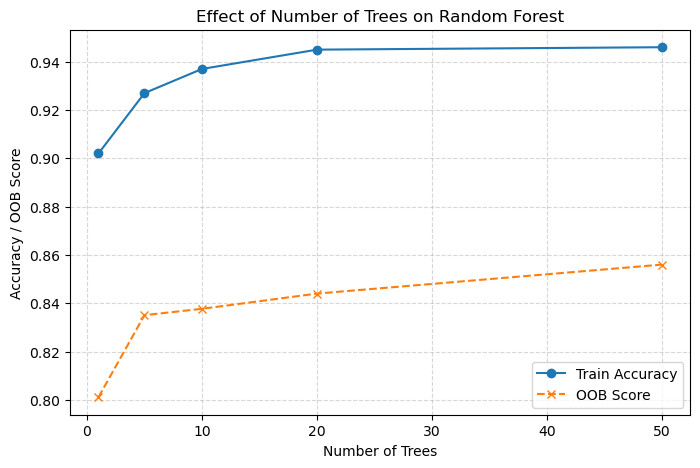

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df_results["ntrees"], df_results["train_accuracy"], marker='o', label="Train Accuracy")
plt.plot(df_results["ntrees"], df_results["oob_score"], marker='x', linestyle='--', label="OOB Score")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy / OOB Score")
plt.title("Effect of Number of Trees on Random Forest")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()



## 5. Visualization Insights

- Accuracy improves with more trees and stabilizes after ~20 trees.  
- OOB score closely approximates true performance on unseen data.  
- Variance decreases as `ntrees` increases, leading to more stable predictions.  

---

## 6. Mathematical Interpretation

Let each tree output be a random variable with variance $\sigma^2$. If trees are independent:

$$
\text{Var}(\text{RF}) = \frac{1}{B} \text{Var}(\text{Tree}) = \frac{\sigma^2}{B}
$$

In practice, trees are correlated ($\rho$):

$$
\text{Var}(\text{RF}) = \rho \sigma^2 + \frac{1-\rho}{B}\sigma^2
$$

Where:

- $B$ = number of trees  
- $\rho$ = correlation between trees  
- $\sigma^2$ = variance of a single tree  

**Insight:** Increasing $B$ reduces variance, improving stability and generalization.

## 7. Conclusions

1. **Variance Reduction:** Increasing the number of trees decreases model variance.  
2. **OOB as a Performance Proxy:** OOB score closely approximates test performance.  
3. **Diminishing Returns:** Beyond ~20 trees, gains in accuracy are marginal.  
4. **Random Forest Robustness:** Handles non-linear and noisy datasets effectively.